In [1]:
# ==========================================================
# 1. Установка библиотек
# ==========================================================
!pip install pillow numpy scikit-image torch torchvision matplotlib -q


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\qweqw\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# ==========================================================
# 2. Импорт и настройки
# ==========================================================
import os
import random
import zipfile

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

# Фиксируем случайность
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Путь к вашим данным
# Для локального запуска:
DATA_DIR = r"D:\prog\python_p\ii\2p_2"

# Для Google Colab потом поменяйте, например:
# DATA_DIR = "/content/dataset"

GRID = 24
FS = 20
IMG_SIZE = GRID * FS  # 480

TRAIN_INPUT_DIR = os.path.join(DATA_DIR, "train", "inputs")
TRAIN_TARGET_DIR = os.path.join(DATA_DIR, "train", "targets")
TEST_DIR = os.path.join(DATA_DIR, "test")

SMOKE_SUBMISSION_DIR = os.path.join(DATA_DIR, "submission_smoke")
os.makedirs(SMOKE_SUBMISSION_DIR, exist_ok=True)

# Настройки именно для ТЕСТОВОГО запуска.
# Нужно, чтобы код быстро отработал и не обучался на всех 7000 картинках.
SMOKE_MAX_TRAIN_IMAGES = 8       # сколько изображений использовать для теста обучения
SMOKE_EPOCHS = 1                 # сколько эпох для теста
SMOKE_NUM_TEST_IMAGES = 1        # сколько тестовых картинок сохранить в тестовый сабмит
SMOKE_NUM_STARTS = 3             # сколько стартовых фрагментов попробовать при сборке
BATCH_SIZE = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
# ==========================================================
# 3. Вспомогательные функции
# ==========================================================
def load_image(path):
    """
    Загружает PNG как RGB-массив numpy размером 480x480x3.
    """
    return np.array(Image.open(path).convert("RGB"))


def get_png_names(directory):
    """
    Возвращает отсортированный список PNG-файлов в папке.
    """
    return sorted([
        name for name in os.listdir(directory)
        if name.lower().endswith(".png")
    ])


def extract_fragments(img):
    """
    Разрезает изображение 480x480 на 576 фрагментов 20x20.
    Возвращает массив формы (576, 20, 20, 3).
    """
    fragments = []
    for r in range(GRID):
        for c in range(GRID):
            fragment = img[r * FS:(r + 1) * FS, c * FS:(c + 1) * FS]
            fragments.append(fragment)
    return np.array(fragments, dtype=np.uint8)


def make_pair_canvas(frag_a, frag_b, orientation="right"):
    """
    Делает канву 40x40 из двух фрагментов 20x20.

    orientation="right":
        [A][B]
        [ ][ ]

    orientation="below":
        [A][ ]
        [B][ ]
    """
    canvas = np.zeros((40, 40, 3), dtype=np.uint8)

    if orientation == "right":
        canvas[0:20, 0:20] = frag_a
        canvas[0:20, 20:40] = frag_b
    else:
        canvas[0:20, 0:20] = frag_a
        canvas[20:40, 0:20] = frag_b

    return canvas

In [4]:
# ==========================================================
# 4. Проверка данных
# ==========================================================
input_names = get_png_names(TRAIN_INPUT_DIR)
target_names = get_png_names(TRAIN_TARGET_DIR)
test_names = get_png_names(TEST_DIR)

print("Train inputs:", len(input_names))
print("Train targets:", len(target_names))
print("Test images:", len(test_names))

# Проверка, что количество входных и целевых изображений совпадает
assert len(input_names) == len(target_names), (
    "Количество файлов в train/inputs и train/targets не совпадает!"
)

# Проверка, что имена файлов совпадают
assert set(input_names) == set(target_names), (
    "Имена файлов в train/inputs и train/targets не совпадают!"
)

# Если у вас действительно 7000 тренировочных и 700 тестовых,
# можно раскомментировать эти проверки:
# assert len(input_names) == 7000, "Ожидалось 7000 тренировочных изображений"
# assert len(test_names) == 700, "Ожидалось 700 тестовых изображений"

print("Проверка данных пройдена.")

Train inputs: 7000
Train targets: 7000
Test images: 700
Проверка данных пройдена.


In [5]:
# ==========================================================
# 5. Разбиение на обучение и валидацию
# ==========================================================
# Из 7000 изображений выделим 700 на валидацию.
# Это нужно, чтобы проверять качество и не трогать их при обучении.

all_train_names = input_names.copy()
random.shuffle(all_train_names)

VAL_SIZE = 700

val_names = all_train_names[:VAL_SIZE]
train_names = all_train_names[VAL_SIZE:]

print("Train split:", len(train_names))
print("Val split:", len(val_names))

Train split: 6300
Val split: 700


In [6]:
# ==========================================================
# 6. Простая модель для проверки пар фрагментов
# ==========================================================
class PairCNN(nn.Module):
    """
    Очень маленькая сеть для тестового пайплайна.

    На вход подаётся пара фрагментов на канве 40x40x3.
    На выходе 3 класса:
        0 - фрагменты не являются нужными соседями,
        1 - второй фрагмент справа от первого,
        2 - второй фрагмент снизу от первого.
    """

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


model = PairCNN().to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Параметров в модели: {num_params:,}")

Параметров в модели: 101,699


In [7]:
# ==========================================================
# 7. Датасет пар для обучения
# ==========================================================
class PairDataset(Dataset):
    """
    Тестовый датасет.

    Берёт чистые изображения из train/targets,
    режет их на фрагменты и создаёт пары:
        - позитивные: настоящие соседи справа или снизу;
        - негативные: случайные пары.
    """

    def __init__(self, names, data_dir, max_images=8):
        self.items = []
        target_dir = os.path.join(data_dir, "train", "targets")

        for name in names[:max_images]:
            img = load_image(os.path.join(target_dir, name))
            fragments = extract_fragments(img)

            positive_pairs = []

            for r in range(GRID):
                for c in range(GRID):
                    idx = r * GRID + c

                    # Пара "справа"
                    if c + 1 < GRID:
                        right_idx = idx + 1
                        pair = make_pair_canvas(
                            fragments[idx],
                            fragments[right_idx],
                            orientation="right"
                        )
                        positive_pairs.append((pair, 1))

                    # Пара "снизу"
                    if r + 1 < GRID:
                        below_idx = idx + GRID
                        pair = make_pair_canvas(
                            fragments[idx],
                            fragments[below_idx],
                            orientation="below"
                        )
                        positive_pairs.append((pair, 2))

            # Создаём примерно столько же негативных пар
            negative_pairs = []

            for _ in range(len(positive_pairs)):
                i1, i2 = random.sample(range(GRID * GRID), 2)
                orientation = random.choice(["right", "below"])

                pair = make_pair_canvas(
                    fragments[i1],
                    fragments[i2],
                    orientation=orientation
                )
                negative_pairs.append((pair, 0))

            self.items.extend(positive_pairs)
            self.items.extend(negative_pairs)

        random.shuffle(self.items)
        print(f"Создано тестовых пар для обучения: {len(self.items):,}")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        pair, label = self.items[idx]

        # HWC -> CHW, uint8 -> float32, нормализация в [0, 1]
        x = torch.from_numpy(pair.copy()).permute(2, 0, 1).float() / 255.0
        y = int(label)

        return x, y


train_dataset = PairDataset(
    names=train_names,
    data_dir=DATA_DIR,
    max_images=SMOKE_MAX_TRAIN_IMAGES
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

Создано тестовых пар для обучения: 17,664


In [8]:
# ==========================================================
# 8. Быстрое тестовое обучение
# ==========================================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(SMOKE_EPOCHS):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        predictions = logits.argmax(dim=1)
        correct += (predictions == y).sum().item()
        total += x.size(0)

    avg_loss = total_loss / max(1, total)
    accuracy = correct / max(1, total)

    print(f"Epoch {epoch + 1}/{SMOKE_EPOCHS} | loss={avg_loss:.4f} | acc={accuracy:.4f}")

Epoch 1/1 | loss=0.7853 | acc=0.5418


In [9]:
# ==========================================================
# 9. Подсчёт scores для сборки одного изображения
# ==========================================================
@torch.no_grad()
def compute_pair_scores(model, fragments, batch_size=1024):
    """
    Для каждого фрагмента считаем вероятность,
    что другой фрагмент находится справа или снизу.

    Возвращает две матрицы:
        right_scores[i, j] - вероятность, что j справа от i;
        below_scores[i, j] - вероятность, что j снизу от i.
    """
    model.eval()

    n = len(fragments)

    right_scores = np.zeros((n, n), dtype=np.float32)
    below_scores = np.zeros((n, n), dtype=np.float32)

    for i in range(n):
        others = [j for j in range(n) if j != i]

        pairs_right = np.stack([
            make_pair_canvas(fragments[i], fragments[j], orientation="right")
            for j in others
        ])

        pairs_below = np.stack([
            make_pair_canvas(fragments[i], fragments[j], orientation="below")
            for j in others
        ])

        # Обработка пар "справа"
        x_right = torch.from_numpy(pairs_right).permute(0, 3, 1, 2).float() / 255.0
        probs_right = []

        for start in range(0, len(x_right), batch_size):
            batch = x_right[start:start + batch_size].to(device)
            logits = model(batch)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            probs_right.append(probs)

        probs_right = np.concatenate(probs_right, axis=0)
        right_scores[i, others] = probs_right[:, 1]

        # Обработка пар "снизу"
        x_below = torch.from_numpy(pairs_below).permute(0, 3, 1, 2).float() / 255.0
        probs_below = []

        for start in range(0, len(x_below), batch_size):
            batch = x_below[start:start + batch_size].to(device)
            logits = model(batch)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            probs_below.append(probs)

        probs_below = np.concatenate(probs_below, axis=0)
        below_scores[i, others] = probs_below[:, 2]

    return right_scores, below_scores

In [10]:
# ==========================================================
# 10. Жадная сборка пазла из разных стартовых фрагментов
# ==========================================================
def assemble_with_start(right_scores, below_scores, start_fragment):
    """
    Жадная сборка сетки 24x24.

    ВАЖНО:
    Это тестовая упрощённая версия.
    Она предполагает, что start_fragment может быть верхним левым.
    В финальном решении нужно будет выбирать верхний левый угол умнее.
    """
    n = GRID * GRID

    grid = -np.ones((GRID, GRID), dtype=int)
    used = np.zeros(n, dtype=bool)

    grid[0, 0] = start_fragment
    used[start_fragment] = True

    for r in range(GRID):
        for c in range(GRID):
            if r == 0 and c == 0:
                continue

            best_idx = -1
            best_score = -1e18

            for fragment_id in range(n):
                if used[fragment_id]:
                    continue

                score = 0.0
                count = 0

                # Если слева уже стоит фрагмент
                if c > 0 and grid[r, c - 1] >= 0:
                    left_id = grid[r, c - 1]
                    score += right_scores[left_id, fragment_id]
                    count += 1

                # Если сверху уже стоит фрагмент
                if r > 0 and grid[r - 1, c] >= 0:
                    top_id = grid[r - 1, c]
                    score += below_scores[top_id, fragment_id]
                    count += 1

                if count > 0:
                    score /= count

                if score > best_score:
                    best_score = score
                    best_idx = fragment_id

            grid[r, c] = best_idx
            used[best_idx] = True

    # Посчитаем средний скор собранной сетки
    total_score = 0.0
    total_count = 0

    for r in range(GRID):
        for c in range(GRID):
            current_id = grid[r, c]

            if c + 1 < GRID:
                right_id = grid[r, c + 1]
                total_score += right_scores[current_id, right_id]
                total_count += 1

            if r + 1 < GRID:
                below_id = grid[r + 1, c]
                total_score += below_scores[current_id, below_id]
                total_count += 1

    avg_score = total_score / max(1, total_count)

    return grid, avg_score


def grid_to_canvas(fragments, grid):
    """
    Собирает изображение 480x480 из сетки фрагментов.
    """
    canvas = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

    for r in range(GRID):
        for c in range(GRID):
            fragment_id = grid[r, c]
            canvas[r * FS:(r + 1) * FS, c * FS:(c + 1) * FS] = fragments[fragment_id]

    return canvas


def solve_image(model, image, num_starts=3):
    """
    Тестовая сборка изображения.
    Пробует несколько стартовых фрагментов и выбирает лучший по внутреннему скору.
    """
    fragments = extract_fragments(image)

    right_scores, below_scores = compute_pair_scores(
        model=model,
        fragments=fragments,
        batch_size=1024
    )

    best_grid = None
    best_score = -1e18

    num_starts = min(num_starts, len(fragments))

    for start_id in range(num_starts):
        grid, score = assemble_with_start(
            right_scores=right_scores,
            below_scores=below_scores,
            start_fragment=start_id
        )

        if score > best_score:
            best_score = score
            best_grid = grid

    result_image = grid_to_canvas(fragments, best_grid)

    return result_image

Проверяем изображение: img_000434.png
Smoke SSIM: 0.1038


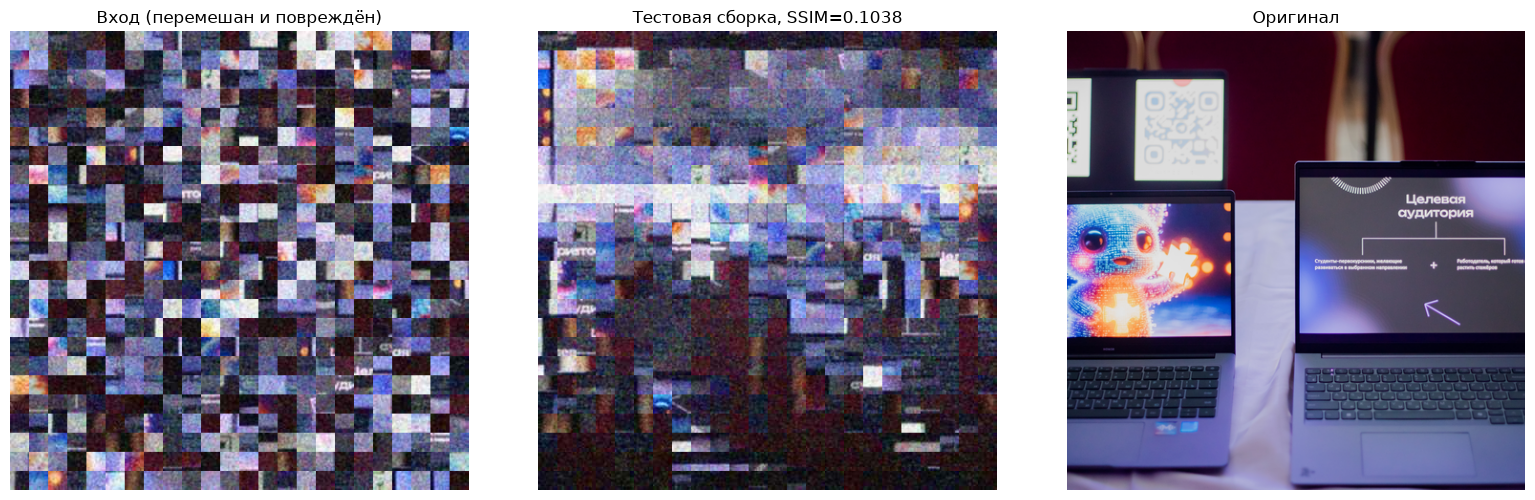

In [11]:
# ==========================================================
# 11. Проверка на одном валидационном изображении
# ==========================================================
val_name = val_names[0]

input_path = os.path.join(TRAIN_INPUT_DIR, val_name)
target_path = os.path.join(TRAIN_TARGET_DIR, val_name)

input_image = load_image(input_path)
target_image = load_image(target_path)

print("Проверяем изображение:", val_name)

result_image = solve_image(
    model=model,
    image=input_image,
    num_starts=SMOKE_NUM_STARTS
)

score = ssim(
    target_image,
    result_image,
    channel_axis=2,
    data_range=255
)

print(f"Smoke SSIM: {score:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(input_image)
axes[0].set_title("Вход (перемешан и повреждён)")
axes[0].axis("off")

axes[1].imshow(result_image)
axes[1].set_title(f"Тестовая сборка, SSIM={score:.4f}")
axes[1].axis("off")

axes[2].imshow(target_image)
axes[2].set_title("Оригинал")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [12]:
# ==========================================================
# 12. Создание тестового сабмита
# ==========================================================
# Очищаем папку submission_smoke, если там уже что-то было
for filename in os.listdir(SMOKE_SUBMISSION_DIR):
    file_path = os.path.join(SMOKE_SUBMISSION_DIR, filename)
    if os.path.isfile(file_path):
        os.remove(file_path)

# Обрабатываем только несколько тестовых изображений,
# потому что полный прогон 700 изображений пока будет долгим.
for test_name in test_names[:SMOKE_NUM_TEST_IMAGES]:
    test_path = os.path.join(TEST_DIR, test_name)
    test_image = load_image(test_path)

    print("Обрабатываем тестовое изображение:", test_name)

    predicted_image = solve_image(
        model=model,
        image=test_image,
        num_starts=SMOKE_NUM_STARTS
    )

    save_path = os.path.join(SMOKE_SUBMISSION_DIR, test_name)
    Image.fromarray(predicted_image).save(save_path)

# Упаковываем тестовый сабмит
smoke_zip_path = os.path.join(DATA_DIR, "submission_smoke.zip")

with zipfile.ZipFile(smoke_zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for filename in sorted(os.listdir(SMOKE_SUBMISSION_DIR)):
        file_path = os.path.join(SMOKE_SUBMISSION_DIR, filename)
        zf.write(file_path, arcname=filename)

print("Тестовый сабмит создан здесь:")
print(smoke_zip_path)

Обрабатываем тестовое изображение: img_000000.png
Тестовый сабмит создан здесь:
D:\prog\python_p\ii\2p_2\submission_smoke.zip


In [ ]:
# ==========================================================
# Улучшенный шаг: аугментации фрагментов + лучший старт
# Запускать после базовых настроек и разбивки данных
# ==========================================================
from PIL import ImageFilter

# Сколько изображений использовать для улучшенного обучения.
# Если работает медленно или мало видеопамяти, уменьшите до 30-50.
AUG_MAX_TRAIN_IMAGES = 80
AUG_EPOCHS = 3
AUG_BATCH_SIZE = 128

# Сколько кандидатов на верхний левый угол пробовать при сборке
NUM_START_CANDIDATES = 20


def corrupt_fragment(frag):
    """
    Имитирует повреждения одного фрагмента:
    - контраст;
    - яркость;
    - небольшое размытие;
    - шум.
    """
    x = frag.astype(np.float32)

    # Контраст
    contrast = np.random.uniform(0.7, 1.3)
    x = (x - 128.0) * contrast + 128.0

    # Яркость
    x += np.random.uniform(-30.0, 30.0)

    x = np.clip(x, 0, 255).astype(np.uint8)

    # Размытие
    if np.random.random() < 0.8:
        x = np.array(
            Image.fromarray(x).filter(
                ImageFilter.GaussianBlur(radius=1)
            )
        )

    # Шум
    # По условию шум может быть очень сильным.
    # Для начала используем 15-45, чтобы модель успела обучиться.
    sigma = np.random.uniform(15.0, 45.0)
    noise = np.random.normal(0.0, sigma, x.shape).astype(np.float32)

    x = x.astype(np.float32) + noise
    x = np.clip(x, 0, 255).astype(np.uint8)

    return x


def make_pair_canvas(frag_a, frag_b, orientation="right"):
    """
    Делает канву 40x40 из двух фрагментов 20x20.
    """
    canvas = np.zeros((40, 40, 3), dtype=np.uint8)

    if orientation == "right":
        canvas[0:20, 0:20] = frag_a
        canvas[0:20, 20:40] = frag_b
    else:
        canvas[0:20, 0:20] = frag_a
        canvas[20:40, 0:20] = frag_b

    return canvas


class PairCNN(nn.Module):
    """
    Небольшая сеть для оценки пары фрагментов.
    """
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


class AugmentedPairDataset(Dataset):
    """
    Датасет, который берёт чистые фрагменты из targets,
    но во время обучения случайно портит их,
    чтобы модель привыкла к шумным и размытым фрагментам.
    """

    def __init__(self, names, data_dir, max_images=80):
        target_dir = os.path.join(data_dir, "train", "targets")

        self.frags_list = []
        self.items = []

        for name in names[:max_images]:
            img = load_image(os.path.join(target_dir, name))
            frags = extract_fragments(img)

            img_idx = len(self.frags_list)
            self.frags_list.append(frags)

            positive_pairs = []

            for r in range(GRID):
                for c in range(GRID):
                    idx = r * GRID + c

                    if c + 1 < GRID:
                        positive_pairs.append((idx, idx + 1, 1, "right"))

                    if r + 1 < GRID:
                        positive_pairs.append((idx, idx + GRID, 2, "below"))

            negative_pairs = []

            for _ in range(len(positive_pairs)):
                i1, i2 = random.sample(range(GRID * GRID), 2)
                orientation = random.choice(["right", "below"])
                negative_pairs.append((i1, i2, 0, orientation))

            for i, j, label, orientation in positive_pairs:
                self.items.append((img_idx, i, j, label, orientation))

            for i, j, label, orientation in negative_pairs:
                self.items.append((img_idx, i, j, label, orientation))

        random.shuffle(self.items)
        print(f"Создано улучшенных пар для обучения: {len(self.items):,}")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_idx, i, j, label, orientation = self.items[idx]

        frags = self.frags_list[img_idx]

        frag_a = corrupt_fragment(frags[i])
        frag_b = corrupt_fragment(frags[j])

        pair = make_pair_canvas(frag_a, frag_b, orientation=orientation)

        x = torch.from_numpy(pair.copy()).permute(2, 0, 1).float() / 255.0
        y = int(label)

        return x, y


# Создаём улучшенный датасет и обучение
aug_dataset = AugmentedPairDataset(
    names=train_names,
    data_dir=DATA_DIR,
    max_images=AUG_MAX_TRAIN_IMAGES
)

aug_loader = DataLoader(
    aug_dataset,
    batch_size=AUG_BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

model = PairCNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(AUG_EPOCHS):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in aug_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        predictions = logits.argmax(dim=1)
        correct += (predictions == y).sum().item()
        total += x.size(0)

    avg_loss = total_loss / max(1, total)
    accuracy = correct / max(1, total)

    print(f"Aug epoch {epoch + 1}/{AUG_EPOCHS} | loss={avg_loss:.4f} | acc={accuracy:.4f}")

In [ ]:
@torch.no_grad()
def compute_pair_scores(model, fragments, batch_size=1024):
    """
    Считаем вероятность, что фрагмент j находится справа от i,
    и что фрагмент j находится снизу от i.
    """
    model.eval()

    n = len(fragments)

    right_scores = np.zeros((n, n), dtype=np.float32)
    below_scores = np.zeros((n, n), dtype=np.float32)

    for i in range(n):
        others = [j for j in range(n) if j != i]

        pairs_right = np.stack([
            make_pair_canvas(fragments[i], fragments[j], orientation="right")
            for j in others
        ])

        pairs_below = np.stack([
            make_pair_canvas(fragments[i], fragments[j], orientation="below")
            for j in others
        ])

        # Пары "справа"
        x_right = torch.from_numpy(pairs_right).permute(0, 3, 1, 2).float() / 255.0
        probs_right = []

        for start in range(0, len(x_right), batch_size):
            batch = x_right[start:start + batch_size].to(device)
            logits = model(batch)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            probs_right.append(probs)

        probs_right = np.concatenate(probs_right, axis=0)
        right_scores[i, others] = probs_right[:, 1]

        # Пары "снизу"
        x_below = torch.from_numpy(pairs_below).permute(0, 3, 1, 2).float() / 255.0
        probs_below = []

        for start in range(0, len(x_below), batch_size):
            batch = x_below[start:start + batch_size].to(device)
            logits = model(batch)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            probs_below.append(probs)

        probs_below = np.concatenate(probs_below, axis=0)
        below_scores[i, others] = probs_below[:, 2]

    return right_scores, below_scores


def choose_start_candidates(right_scores, below_scores, num_starts=20):
    """
    Пытаемся найти фрагменты, которые похожи на верхний левый угол.

    Идея:
    - у верхнего левого фрагмента должны быть хорошие продолжения
      справа и снизу;
    - но на него самого не должны сильно указывать другие фрагменты
      как на правого или нижнего соседа.
    """
    outgoing = right_scores.max(axis=1) + below_scores.max(axis=1)
    incoming = right_scores.max(axis=0) + below_scores.max(axis=0)

    corner_score = outgoing - incoming

    candidates = np.argsort(-corner_score)
    return candidates[:num_starts]


def assemble_with_start_fast(right_scores, below_scores, start_fragment):
    """
    Более быстрая жадная сборка.
    """
    n = right_scores.shape[0]

    grid = -np.ones((GRID, GRID), dtype=int)
    used = np.zeros(n, dtype=bool)

    grid[0, 0] = start_fragment
    used[start_fragment] = True

    for r in range(GRID):
        for c in range(GRID):
            if r == 0 and c == 0:
                continue

            scores = np.zeros(n, dtype=np.float32)
            count = 0

            if c > 0 and grid[r, c - 1] >= 0:
                left_id = grid[r, c - 1]
                scores += right_scores[left_id]
                count += 1

            if r > 0 and grid[r - 1, c] >= 0:
                top_id = grid[r - 1, c]
                scores += below_scores[top_id]
                count += 1

            if count > 0:
                scores /= count

            scores[used] = -1e18

            best_idx = int(np.argmax(scores))
            grid[r, c] = best_idx
            used[best_idx] = True

    # Оценка собранной сетки
    total_score = 0.0
    total_count = 0

    for r in range(GRID):
        for c in range(GRID):
            current_id = grid[r, c]

            if c + 1 < GRID:
                right_id = grid[r, c + 1]
                total_score += right_scores[current_id, right_id]
                total_count += 1

            if r + 1 < GRID:
                below_id = grid[r + 1, c]
                total_score += below_scores[current_id, below_id]
                total_count += 1

    avg_score = total_score / max(1, total_count)

    return grid, avg_score


def grid_to_canvas(fragments, grid):
    """
    Собирает изображение 480x480 из сетки фрагментов.
    """
    canvas = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

    for r in range(GRID):
        for c in range(GRID):
            fragment_id = grid[r, c]
            canvas[r * FS:(r + 1) * FS, c * FS:(c + 1) * FS] = fragments[fragment_id]

    return canvas


def solve_image_v2(model, image, num_starts=20):
    """
    Улучшенная сборка:
    1. Считаем scores.
    2. Выбираем кандидатов на верхний левый угол.
    3. Пробуем собрать пазл от каждого кандидата.
    4. Выбираем лучшую сборку.
    """
    fragments = extract_fragments(image)

    right_scores, below_scores = compute_pair_scores(
        model=model,
        fragments=fragments,
        batch_size=1024
    )

    start_candidates = choose_start_candidates(
        right_scores=right_scores,
        below_scores=below_scores,
        num_starts=num_starts
    )

    best_grid = None
    best_score = -1e18

    for start_id in start_candidates:
        grid, score = assemble_with_start_fast(
            right_scores=right_scores,
            below_scores=below_scores,
            start_fragment=int(start_id)
        )

        if score > best_score:
            best_score = score
            best_grid = grid

    result_image = grid_to_canvas(fragments, best_grid)

    return result_image

In [ ]:
val_name = val_names[0]

input_path = os.path.join(TRAIN_INPUT_DIR, val_name)
target_path = os.path.join(TRAIN_TARGET_DIR, val_name)

input_image = load_image(input_path)
target_image = load_image(target_path)

print("Проверяем изображение:", val_name)

result_image_v2 = solve_image_v2(
    model=model,
    image=input_image,
    num_starts=NUM_START_CANDIDATES
)

score_v2 = ssim(
    target_image,
    result_image_v2,
    channel_axis=2,
    data_range=255
)

print(f"Improved smoke SSIM: {score_v2:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(input_image)
axes[0].set_title("Вход (перемешан и повреждён)")
axes[0].axis("off")

axes[1].imshow(result_image_v2)
axes[1].set_title(f"Улучшенная сборка, SSIM={score_v2:.4f}")
axes[1].axis("off")

axes[2].imshow(target_image)
axes[2].set_title("Оригинал")
axes[2].axis("off")

plt.tight_layout()
plt.show()